# 🎬 Movie Rating Prediction: Modular Workflow
---
**Developer:** POOJITHA  
**Domain:** DATA SCIENCE  
**Objective:** Build a machine learning model to predict movie ratings based on genre, director, and actors.

In [1]:
%pip install plotly

# Importing Libraries for Time Series Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import plotly.express as px
except ImportError:
    %pip install plotly
    import plotly.express as px


# Importing Libraries for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_regression

# For feature engineering and model evaluation
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score

# For seasonal decomposition and plots
from matplotlib import dates as mdates
import matplotlib.ticker as ticker
try:
    from wordcloud import WordCloud
except ImportError:
    %pip install wordcloud
    from wordcloud import WordCloud

# Other useful libraries
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:


df = pd.read_csv("imdb_data.csv")

In [3]:
# Display the first few rows to understand the dataset structure
# This helps us see:
# - Column names and types
# - Sample data values
# - Initial data quality
df.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,-1997.0,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,-2005.0,142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,-2008.0,59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,-2012.0,82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,-2014.0,116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [4]:
# Check dataset dimensions
# Returns (number_of_rows, number_of_columns)
# This tells us how much data we're working with
df.shape # Check the number of rows and columns in the dataset to understand its size and dimensionality.

(15509, 10)

In [5]:
# Get comprehensive information about the dataset:
# - Data types of each column
# - Number of non-null values (helps identify missing data)
# - Memory usage
df.info() # Get a concise summary of the DataFrame, including data types and non-null counts, to identify potential issues with missing data or incorrect data types.

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(2), str(8)
memory usage: 1.2 MB


In [6]:
# Generate descriptive statistics for all columns
# For numerical columns: count, mean, std, min, max, quartiles
# For categorical columns: count, unique values, most frequent
df.describe(include='all') # Generate descriptive statistics for all columns, including count, unique values, top values, frequency, mean, std, min, 25th percentile, 50th percentile, 75th percentile, and max. This helps in understanding the distribution and central tendencies of the data.

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981.000000,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,NaN,182,485,NaN,2034,5938,4718,4891,4820
top,Anjaam,NaN,120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,NaN,240,2780,NaN,227,58,158,83,91
mean,NaN,-1987.012215,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,25.416689,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,-2022.000000,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,-2009.000000,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,-1991.000000,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,-1968.000000,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


In [7]:
# Count missing values in each column
# Missing data can affect our analysis and models
# We need to handle these before modeling
df.isnull().sum() # Check for missing values in each column to identify if any data cleaning or imputation is necessary before analysis.

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [8]:
# Remove duplicate movie entries based on movie Name
# Duplicates can skew our analysis and model training
# We keep only unique movies in the dataset
df.drop_duplicates(subset='Name',inplace=True)
df.duplicated().value_counts()  # Check for duplicate entries in the dataset based on the 'Name' column and remove them to ensure data integrity. After dropping duplicates, we check again to confirm that there are no remaining duplicate entries.

False    13838
Name: count, dtype: int64

In [9]:
# Display the first few rows to understand the dataset structure
# This helps us see:
# - Column names and types
# - Sample data values
# - Initial data quality
df = df.drop(df.index[0]).reset_index(drop=True)
movie = df
movie.head() # Display the first few rows of the cleaned dataset to confirm that duplicates have been removed and the index has been reset properly.

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
1,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
2,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
3,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
4,...Aur Pyaar Ho Gaya,-1997.0,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor


In [10]:
# Count missing values in each column
# Missing data can affect our analysis and models
# We need to handle these before modeling
df.isnull().sum().sort_values(ascending=False)/len(df) # Calculate the percentage of missing values in each column to assess the extent of missing data and determine if any columns should be dropped or if imputation is necessary. Sorting the values in descending order helps to quickly identify columns with the highest percentage of missing data.

Duration    0.523090
Rating      0.483053
Votes       0.482980
Actor 3     0.202717
Actor 2     0.154080
Genre       0.114909
Actor 1     0.103997
Year        0.035918
Director    0.033606
Name        0.000000
dtype: float64

In [11]:
print("umber of rows:", movie.shape[0])
print("Number of columns:", movie.shape[1]) # Print the number of rows and columns in the cleaned dataset to confirm the size of the data after removing duplicates and resetting the index.

umber of rows: 13837
Number of columns: 10


In [12]:
df.duplicated().sum() # Check for any remaining duplicate entries in the dataset after dropping duplicates based on the 'Name' column to ensure that there are no duplicate records left in the data.

np.int64(0)

In [13]:
df.dropna(inplace=True) # Remove any rows with missing values to ensure that the dataset is complete and ready for analysis. This step is crucial for maintaining data integrity and avoiding issues during modeling or visualization. After dropping rows with missing values, we can proceed with further analysis or modeling without concerns about incomplete data.

In [14]:
# Check dataset dimensions
# Returns (number_of_rows, number_of_columns)
# This tells us how much data we're working with
df.shape # Check the number of rows and columns in the dataset to understand its size and dimensionality.

(5148, 10)

In [15]:
# Count missing values in each column
# Missing data can affect our analysis and models
# We need to handle these before modeling
df.isnull().sum() # Check for missing values in each column to identify if 
# any data cleaning or imputation is necessary before analysis.

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [16]:
# Remove duplicate movie entries based on movie Name
# Duplicates can skew our analysis and model training
# We keep only unique movies in the dataset
df.drop_duplicates(inplace=True) 
# Remove any duplicate rows from the dataset 
# to ensure that each record is unique and to prevent bias in analysis and modeling.

In [17]:
# Check dataset dimensions
# Returns (number_of_rows, number_of_columns)
# This tells us how much data we're working with
df.shape 

(5148, 10)

In [18]:
df.columns 

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='str')

In [19]:
# Check dataset dimensions
# Returns (number_of_rows, number_of_columns)
# This tells us how much data we're working with
df.drop_duplicates(subset=['Name', 'Year'], inplace=True)
df.shape

(5148, 10)

In [20]:
dummies = df['Genre'].str.get_dummies(sep=', ')
df_genre = pd.concat([df, dummies], axis=1)
df_genre = df_genre.replace(0, np.nan)
df_genre.drop(['Name','Year','Duration','Genre','Rating','Votes','Director','Actor 1','Actor 2','Actor 3'], axis=1).sum().sort_values(ascending=False)

Drama          3455.0
Action         1500.0
Comedy         1262.0
Romance        1244.0
Crime           787.0
Thriller        604.0
Musical         372.0
Family          371.0
Mystery         269.0
Adventure       251.0
Horror          181.0
Fantasy         131.0
Biography       110.0
History          95.0
Music            52.0
Documentary      47.0
Animation        39.0
Sport            39.0
War              32.0
Sci-Fi           29.0
News              1.0
Western           1.0
dtype: float64

<Axes: title={'center': 'Top 10 Movie Genres'}>

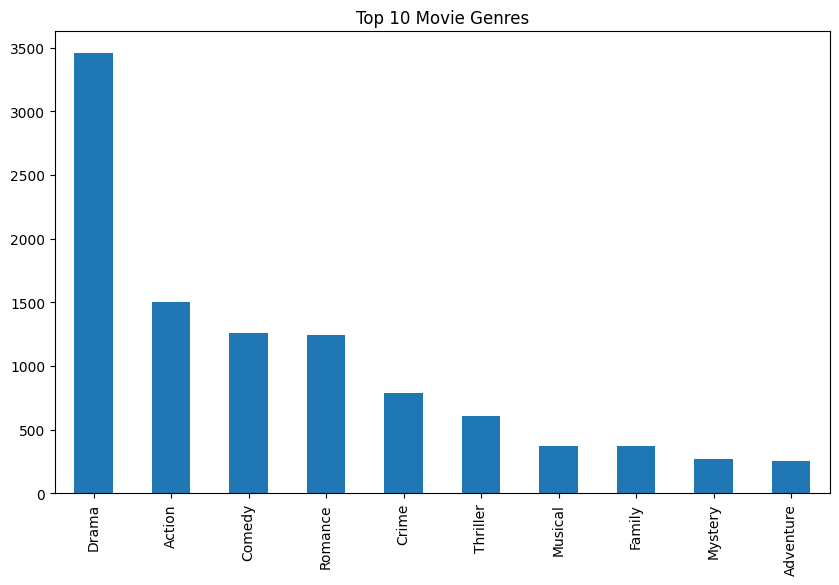

In [21]:
top_genres = df_genre.drop(['Name','Year','Duration','Genre','Rating','Votes','Director','Actor 1','Actor 2','Actor 3'], axis=1).sum().sort_values(ascending=False).head(10)
top_genres.plot(kind='bar', figsize=(10,6), title='Top 10 Movie Genres')   


In [22]:
# Top 10 directors by number of movies and bar plot
Director_Year = df[['Director','Year']].dropna()
Director_Year['Count'] = 1
Director_Top = Director_Year['Director'].value_counts().rename_axis('Director').reset_index(name='Count')

In [23]:
fig = px.bar(Director_Top[0:20],
             x='Director',
             y='Count',
             title = 'Top 20 Director by number of Movies made')
fig.show()

In [24]:
Top_Director = Director_Top[0:20]['Director']
Director_Year = Director_Year[Director_Year['Director'].isin(Top_Director)].set_index('Director').loc[Top_Director].reset_index(level=0)
Director_Year = Director_Year.sort_values('Year')
Director_Year['Year'] =  pd.to_datetime(Director_Year['Year'])

In [25]:
fig = px.strip(Director_Year,
               x="Year",
               y='Director',
               color = "Director",
               color_discrete_sequence=px.colors.qualitative.Dark24,
               height = 600,
               title = 'Top 20 Director by number of Movies made through the Years')
fig.show()

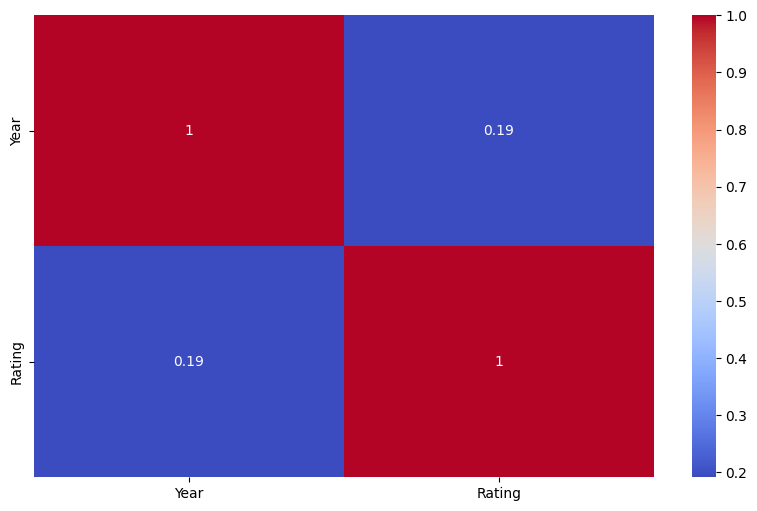

In [26]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


In [27]:
from sklearn.ensemble import GradientBoostingRegressor


models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoost": GradientBoostingRegressor()
}


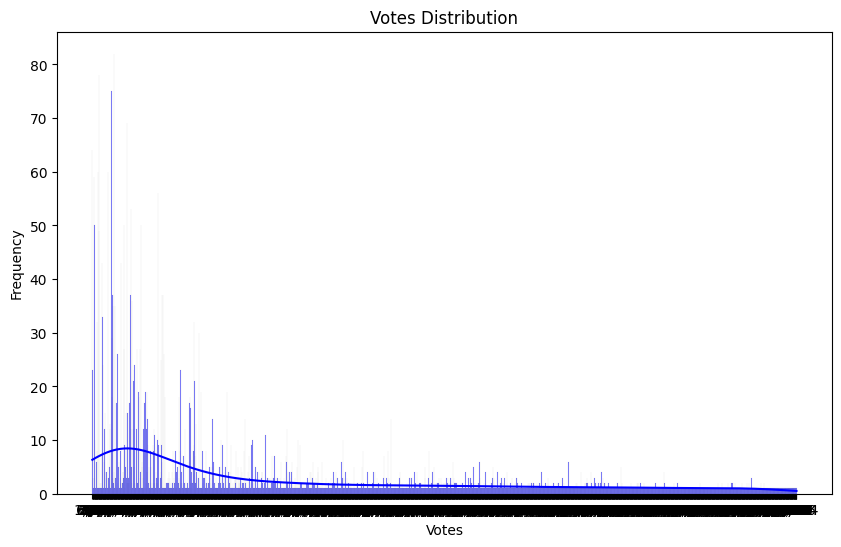

In [28]:
# Create histogram to visualize the distribution of values
# This shows:
# - The shape of the distribution (normal, skewed, etc.)
# - Most common value ranges
# - Presence of outliers
plt.figure(figsize=(10, 6))
sns.histplot(movie['Votes'], kde=True, bins=30, color='blue')
plt.title('Votes Distribution')
plt.xlabel('Votes')
plt.ylabel('Frequency')
plt.show()

# Data Preprocessing for Machine Learning

Before building our models, we need to:
1. Clean numerical features (Duration, Year, Votes)
2. Encode categorical features (Genre, Director, Actors)
3. Split data into training and testing sets

In [29]:
# Clean Duration: Convert to string, remove ' min', and convert back to numeric
movie['Duration'] = movie['Duration'].astype(str).str.replace(' min', '', regex=False)
movie['Duration'] = pd.to_numeric(movie['Duration'], errors='coerce')
movie['Duration'] = movie['Duration'].fillna(movie['Duration'].mean())

# Clean Year: Convert negative years to absolute values
movie['Year'] = movie['Year'].abs()
movie['Year'] = movie['Year'].fillna(movie['Year'].mean())

# Clean Votes: Remove commas and convert to numeric
movie['Votes'] = movie['Votes'].astype(str).str.replace(',', '', regex=False)
movie['Votes'] = pd.to_numeric(movie['Votes'], errors='coerce')
movie['Votes'] = movie['Votes'].fillna(0)

print('Numerical features cleaned successfully!')
print(f"Duration range: {movie['Duration'].min():.0f} - {movie['Duration'].max():.0f} min")
print(f"Year range: {movie['Year'].min():.0f} - {movie['Year'].max():.0f}")
print(f"Votes range: {movie['Votes'].min():.0f} - {movie['Votes'].max():.0f}")

Numerical features cleaned successfully!
Duration range: 21 - 321 min
Year range: 1931 - 2021
Votes range: 5 - 591417


In [30]:
# Fill missing values in categorical columns with 'Unknown'
# Use direct assignment instead of inplace
categorical_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in categorical_cols:
    movie[col] = movie[col].fillna('Unknown')

# Fill missing ratings with mean
movie['Rating'] = movie['Rating'].fillna(movie['Rating'].mean())

print('Missing values handled!')
print(f"\nRemaining null values:\n{movie.isnull().sum()}")

Missing values handled!

Remaining null values:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


## Categorical Feature Encoding

We use **Label Encoding** to convert categorical features (Genre, Director, Actors) into numerical values that our models can understand.

In [31]:
# Create a copy for modeling
df_model = movie.copy()

# Initialize Label Encoders
from sklearn.preprocessing import LabelEncoder

genre_encoder = LabelEncoder()
director_encoder = LabelEncoder()
actor1_encoder = LabelEncoder()
actor2_encoder = LabelEncoder()
actor3_encoder = LabelEncoder()

# Encode categorical features
df_model['Genre_Encoded'] = genre_encoder.fit_transform(df_model['Genre'])
df_model['Director_Encoded'] = director_encoder.fit_transform(df_model['Director'])
df_model['Actor1_Encoded'] = actor1_encoder.fit_transform(df_model['Actor 1'])
df_model['Actor2_Encoded'] = actor2_encoder.fit_transform(df_model['Actor 2'])
df_model['Actor3_Encoded'] = actor3_encoder.fit_transform(df_model['Actor 3'])

print('Categorical features encoded!')
print(f"\nEncoded columns preview:")
print(df_model[['Genre', 'Genre_Encoded', 'Director', 'Director_Encoded']].head())

Categorical features encoded!

Encoded columns preview:
                       Genre  Genre_Encoded        Director  Director_Encoded
0                      Drama            221   Gaurav Bakshi               613
2            Comedy, Romance            178      Ovais Khan              1299
4     Comedy, Drama, Musical            152    Rahul Rawail              1488
5        Drama, Romance, War            279  Shoojit Sircar              1983
7  Horror, Mystery, Thriller            308   Allyson Patel               132


## Train-Test Split

We split our data into:
- **Training Set (80%)**: Used to train our models
- **Testing Set (20%)**: Used to evaluate model performance on unseen data

In [32]:
# Select features for modeling
feature_cols = ['Year', 'Duration', 'Genre_Encoded', 'Votes', 
                'Director_Encoded', 'Actor1_Encoded', 'Actor2_Encoded', 'Actor3_Encoded']

X = df_model[feature_cols]
y = df_model['Rating']

# Drop any remaining NaN values to ensure clean data for modeling
# Create a combined dataframe to drop rows with NaN in either X or y
combined = X.copy()
combined['target'] = y
combined_clean = combined.dropna()

X_clean = combined_clean[feature_cols]
y_clean = combined_clean['target']

# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

print('Data split complete!')
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')
print(f'\nData is clean - no NaN values in features or target')

Data split complete!
Training samples: 4118
Testing samples: 1030
Number of features: 8

Data is clean - no NaN values in features or target


# Model Training

We train three different regression models:
1. **Linear Regression**: Simple baseline model
2. **Random Forest**: Handles non-linear relationships well
3. **Gradient Boosting**: Often provides best performance

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)

# Train models
print('Training Linear Regression...')
lr_model.fit(X_train, y_train)
print('✓ Linear Regression trained')

print('Training Random Forest...')
rf_model.fit(X_train, y_train)
print('✓ Random Forest trained')

print('Training Gradient Boosting...')
gb_model.fit(X_train, y_train)
print('✓ Gradient Boosting trained')

print('\nAll models trained successfully!')

Training Linear Regression...
✓ Linear Regression trained
Training Random Forest...
✓ Random Forest trained
Training Gradient Boosting...
✓ Gradient Boosting trained

All models trained successfully!


# Model Evaluation

We evaluate our models using:
- **Mean Squared Error (MSE)**: Average squared difference between predicted and actual ratings (lower is better)
- **R² Score**: Proportion of variance explained by the model (higher is better, max = 1.0)

In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Calculate metrics
models_results = {
    'Linear Regression': {
        'MSE': mean_squared_error(y_test, lr_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, lr_pred)),
        'R² Score': r2_score(y_test, lr_pred)
    },
    'Random Forest': {
        'MSE': mean_squared_error(y_test, rf_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
        'R² Score': r2_score(y_test, rf_pred)
    },
    'Gradient Boosting': {
        'MSE': mean_squared_error(y_test, gb_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, gb_pred)),
        'R² Score': r2_score(y_test, gb_pred)
    }
}

# Display results
print('Model Performance Comparison:')
print('=' * 70)
for model_name, metrics in models_results.items():
    print(f"\n{model_name}:")
    print(f"  MSE:      {metrics['MSE']:.4f}")
    print(f"  RMSE:     {metrics['RMSE']:.4f}")
    print(f"  R² Score: {metrics['R² Score']:.4f}")
print('=' * 70)

# Identify best model
best_model_name = max(models_results, key=lambda x: models_results[x]['R² Score'])
print(f"\n🏆 Best Model: {best_model_name} (R² = {models_results[best_model_name]['R² Score']:.4f})")

Model Performance Comparison:

Linear Regression:
  MSE:      1.9134
  RMSE:     1.3832
  R² Score: 0.0753

Random Forest:
  MSE:      1.3722
  RMSE:     1.1714
  R² Score: 0.3368

Gradient Boosting:
  MSE:      1.2888
  RMSE:     1.1352
  R² Score: 0.3772

🏆 Best Model: Gradient Boosting (R² = 0.3772)


## Actual vs Predicted Ratings

Visualizing how well our Random Forest model predicts movie ratings.

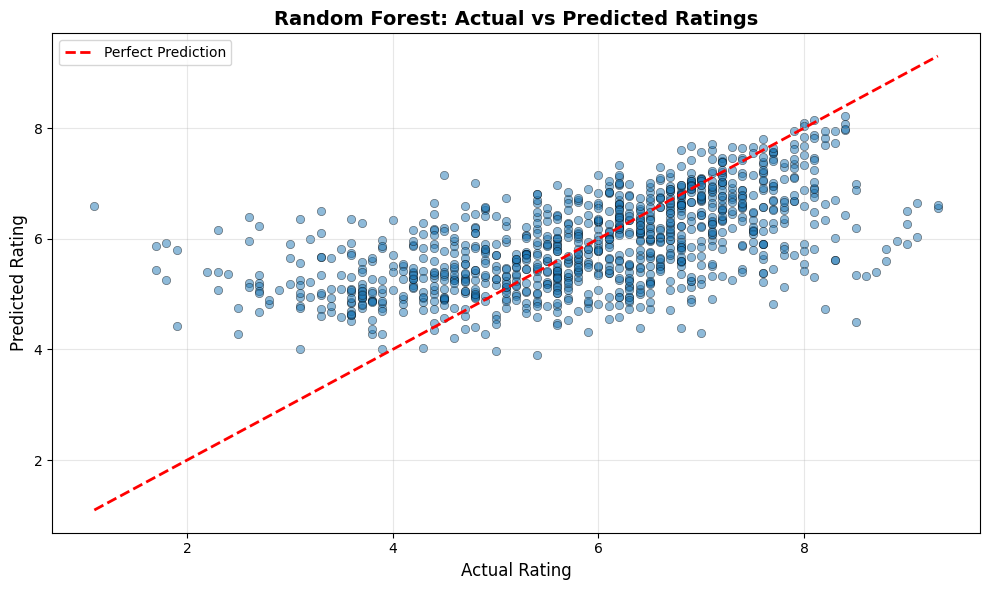

In [35]:
# Create scatter plot to show relationship between two variables
# Each point represents one movie
# Patterns in the scatter can reveal correlations
# Actual vs Predicted plot for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rating', fontsize=12)
plt.ylabel('Predicted Rating', fontsize=12)
plt.title('Random Forest: Actual vs Predicted Ratings', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Importance Analysis

Understanding which features have the most impact on movie ratings helps us:
- Identify key drivers of movie success
- Focus on important factors for predictions
- Gain insights into what makes a highly-rated movie

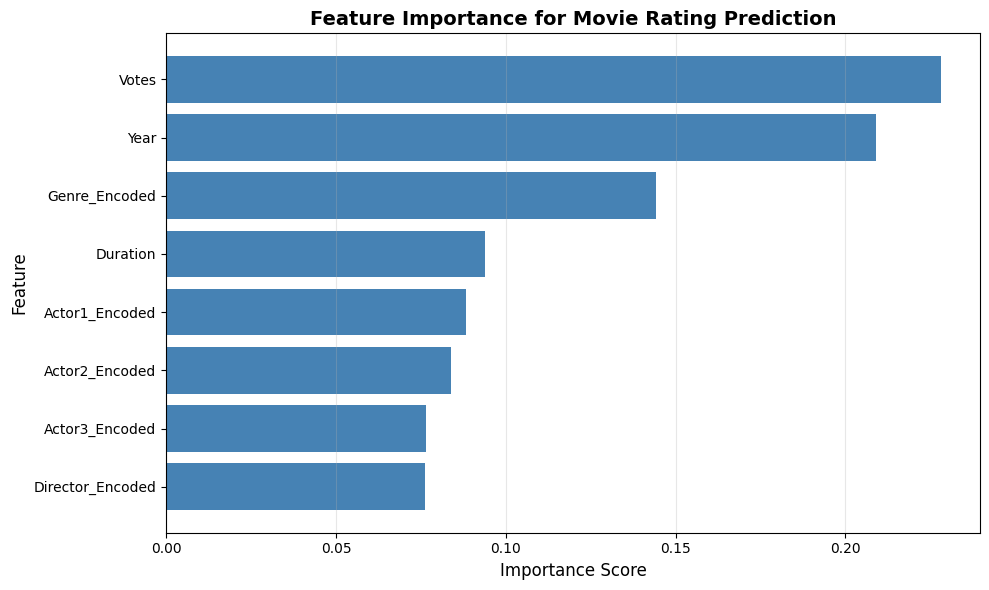


Top 5 Most Important Features:
          Feature  Importance
3           Votes    0.228209
0            Year    0.209120
2   Genre_Encoded    0.144169
1        Duration    0.093930
5  Actor1_Encoded    0.088174


In [36]:
# Extract feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize top features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance for Movie Rating Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print top features
print('\nTop 5 Most Important Features:')
print(feature_importance.head())

# Prediction Function

A helper function to predict ratings for new movies using our trained Random Forest model.

In [37]:
def predict_rating(year, duration, genre, votes, director, actor1, actor2, actor3):
    """
    Predict movie rating using the trained Random Forest model.
    
    Parameters:
    -----------
    year : int - Release year
    duration : int - Movie duration in minutes
    genre : str - Movie genre
    votes : int - Number of votes
    director : str - Director name
    actor1, actor2, actor3 : str - Lead actors
    
    Returns:
    --------
    float - Predicted rating (1-10 scale)
    """
    try:
        # Encode categorical features
        genre_enc = genre_encoder.transform([genre])[0] if genre in genre_encoder.classes_ else -1
        director_enc = director_encoder.transform([director])[0] if director in director_encoder.classes_ else -1
        actor1_enc = actor1_encoder.transform([actor1])[0] if actor1 in actor1_encoder.classes_ else -1
        actor2_enc = actor2_encoder.transform([actor2])[0] if actor2 in actor2_encoder.classes_ else -1
        actor3_enc = actor3_encoder.transform([actor3])[0] if actor3 in actor3_encoder.classes_ else -1
        
        # Create feature array
        features = np.array([[year, duration, genre_enc, votes, director_enc, actor1_enc, actor2_enc, actor3_enc]])
        
        # Make prediction
        prediction = rf_model.predict(features)[0]
        
        # Clip to valid rating range
        prediction = np.clip(prediction, 1, 10)
        
        return round(prediction, 2)
    except Exception as e:
        print(f"Error making prediction: {e}")
        return None

# Test the prediction function
print('Testing Prediction Function:')
print('=' * 50)
test_rating = predict_rating(
    year=2020,
    duration=120,
    genre='Drama',
    votes=10000,
    director='Christopher Nolan',
    actor1='Leonardo DiCaprio',
    actor2='Tom Hardy',
    actor3='Marion Cotillard'
)
print(f"Predicted Rating: {test_rating}/10")
print('=' * 50)

Testing Prediction Function:
Predicted Rating: 6.26/10


# Data Preprocessing for Machine Learning

Before building our models, we need to:
1. Clean numerical features (Duration, Year, Votes)
2. Encode categorical features (Genre, Director, Actors)
3. Split data into training and testing sets

In [38]:
# Clean Duration: Convert to string, remove ' min', and convert back to numeric
movie['Duration'] = movie['Duration'].astype(str).str.replace(' min', '', regex=False)
movie['Duration'] = pd.to_numeric(movie['Duration'], errors='coerce')
movie['Duration'] = movie['Duration'].fillna(movie['Duration'].mean())

# Clean Year: Convert negative years to absolute values
movie['Year'] = movie['Year'].abs()
movie['Year'] = movie['Year'].fillna(movie['Year'].mean())

# Clean Votes: Remove commas and convert to numeric
movie['Votes'] = movie['Votes'].astype(str).str.replace(',', '', regex=False)
movie['Votes'] = pd.to_numeric(movie['Votes'], errors='coerce')
movie['Votes'] = movie['Votes'].fillna(0)

print('Numerical features cleaned successfully!')
print(f"Duration range: {movie['Duration'].min():.0f} - {movie['Duration'].max():.0f} min")
print(f"Year range: {movie['Year'].min():.0f} - {movie['Year'].max():.0f}")
print(f"Votes range: {movie['Votes'].min():.0f} - {movie['Votes'].max():.0f}")

Numerical features cleaned successfully!
Duration range: 21 - 321 min
Year range: 1931 - 2021
Votes range: 5 - 591417


In [39]:
# Fill missing values in categorical columns with 'Unknown'
# Use direct assignment instead of inplace
categorical_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in categorical_cols:
    movie[col] = movie[col].fillna('Unknown')

# Fill missing ratings with mean
movie['Rating'] = movie['Rating'].fillna(movie['Rating'].mean())

print('Missing values handled!')
print(f"\nRemaining null values:\n{movie.isnull().sum()}")

Missing values handled!

Remaining null values:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


## Categorical Feature Encoding

We use **Label Encoding** to convert categorical features (Genre, Director, Actors) into numerical values that our models can understand.

In [40]:
# Create a copy for modeling
df_model = movie.copy()

# Initialize Label Encoders
from sklearn.preprocessing import LabelEncoder

genre_encoder = LabelEncoder()
director_encoder = LabelEncoder()
actor1_encoder = LabelEncoder()
actor2_encoder = LabelEncoder()
actor3_encoder = LabelEncoder()

# Encode categorical features
df_model['Genre_Encoded'] = genre_encoder.fit_transform(df_model['Genre'])
df_model['Director_Encoded'] = director_encoder.fit_transform(df_model['Director'])
df_model['Actor1_Encoded'] = actor1_encoder.fit_transform(df_model['Actor 1'])
df_model['Actor2_Encoded'] = actor2_encoder.fit_transform(df_model['Actor 2'])
df_model['Actor3_Encoded'] = actor3_encoder.fit_transform(df_model['Actor 3'])

print('Categorical features encoded!')
print(f"\nEncoded columns preview:")
print(df_model[['Genre', 'Genre_Encoded', 'Director', 'Director_Encoded']].head())

Categorical features encoded!

Encoded columns preview:
                       Genre  Genre_Encoded        Director  Director_Encoded
0                      Drama            221   Gaurav Bakshi               613
2            Comedy, Romance            178      Ovais Khan              1299
4     Comedy, Drama, Musical            152    Rahul Rawail              1488
5        Drama, Romance, War            279  Shoojit Sircar              1983
7  Horror, Mystery, Thriller            308   Allyson Patel               132


## Train-Test Split

We split our data into:
- **Training Set (80%)**: Used to train our models
- **Testing Set (20%)**: Used to evaluate model performance on unseen data

In [41]:
# Select features for modeling
feature_cols = ['Year', 'Duration', 'Genre_Encoded', 'Votes', 
                'Director_Encoded', 'Actor1_Encoded', 'Actor2_Encoded', 'Actor3_Encoded']

X = df_model[feature_cols]
y = df_model['Rating']

# Drop any remaining NaN values to ensure clean data for modeling
# Create a combined dataframe to drop rows with NaN in either X or y
combined = X.copy()
combined['target'] = y
combined_clean = combined.dropna()

X_clean = combined_clean[feature_cols]
y_clean = combined_clean['target']

# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

print('Data split complete!')
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')
print(f'\nData is clean - no NaN values in features or target')

Data split complete!
Training samples: 4118
Testing samples: 1030
Number of features: 8

Data is clean - no NaN values in features or target


# Model Training

We train three different regression models:
1. **Linear Regression**: Simple baseline model
2. **Random Forest**: Handles non-linear relationships well
3. **Gradient Boosting**: Often provides best performance

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)

# Train models
print('Training Linear Regression...')
lr_model.fit(X_train, y_train)
print('✓ Linear Regression trained')

print('Training Random Forest...')
rf_model.fit(X_train, y_train)
print('✓ Random Forest trained')

print('Training Gradient Boosting...')
gb_model.fit(X_train, y_train)
print('✓ Gradient Boosting trained')

print('\nAll models trained successfully!')

Training Linear Regression...
✓ Linear Regression trained
Training Random Forest...
✓ Random Forest trained
Training Gradient Boosting...
✓ Gradient Boosting trained

All models trained successfully!


# Model Evaluation

We evaluate our models using:
- **Mean Squared Error (MSE)**: Average squared difference between predicted and actual ratings (lower is better)
- **R² Score**: Proportion of variance explained by the model (higher is better, max = 1.0)

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Calculate metrics
models_results = {
    'Linear Regression': {
        'MSE': mean_squared_error(y_test, lr_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, lr_pred)),
        'R² Score': r2_score(y_test, lr_pred)
    },
    'Random Forest': {
        'MSE': mean_squared_error(y_test, rf_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
        'R² Score': r2_score(y_test, rf_pred)
    },
    'Gradient Boosting': {
        'MSE': mean_squared_error(y_test, gb_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, gb_pred)),
        'R² Score': r2_score(y_test, gb_pred)
    }
}

# Display results
print('Model Performance Comparison:')
print('=' * 70)
for model_name, metrics in models_results.items():
    print(f"\n{model_name}:")
    print(f"  MSE:      {metrics['MSE']:.4f}")
    print(f"  RMSE:     {metrics['RMSE']:.4f}")
    print(f"  R² Score: {metrics['R² Score']:.4f}")
print('=' * 70)

# Identify best model
best_model_name = max(models_results, key=lambda x: models_results[x]['R² Score'])
print(f"\n🏆 Best Model: {best_model_name} (R² = {models_results[best_model_name]['R² Score']:.4f})")

Model Performance Comparison:

Linear Regression:
  MSE:      1.9134
  RMSE:     1.3832
  R² Score: 0.0753

Random Forest:
  MSE:      1.3722
  RMSE:     1.1714
  R² Score: 0.3368

Gradient Boosting:
  MSE:      1.2888
  RMSE:     1.1352
  R² Score: 0.3772

🏆 Best Model: Gradient Boosting (R² = 0.3772)


## Actual vs Predicted Ratings

Visualizing how well our Random Forest model predicts movie ratings.

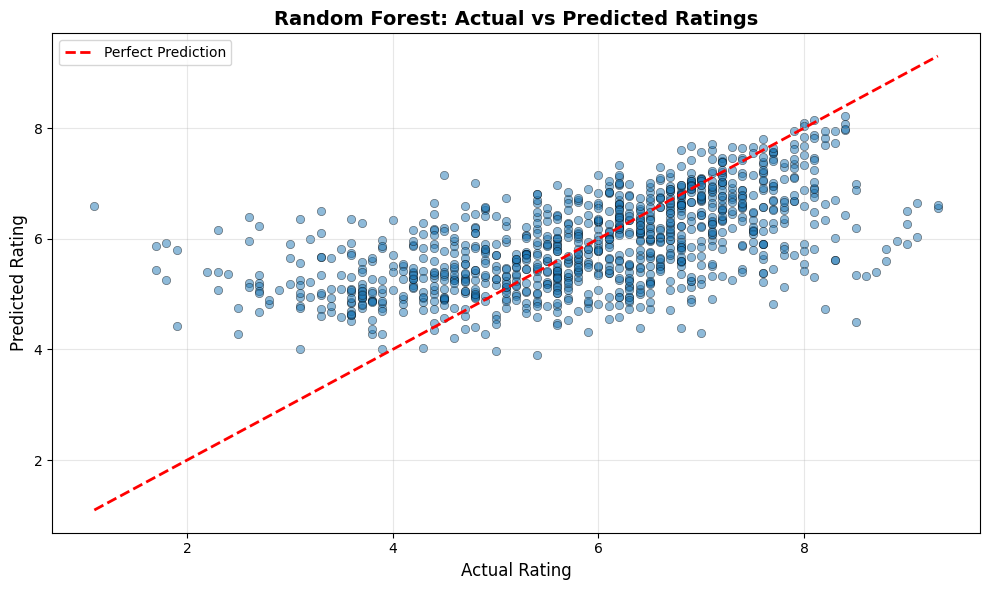

In [44]:
# Create scatter plot to show relationship between two variables
# Each point represents one movie
# Patterns in the scatter can reveal correlations
# Actual vs Predicted plot for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rating', fontsize=12)
plt.ylabel('Predicted Rating', fontsize=12)
plt.title('Random Forest: Actual vs Predicted Ratings', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Importance Analysis

Understanding which features have the most impact on movie ratings helps us:
- Identify key drivers of movie success
- Focus on important factors for predictions
- Gain insights into what makes a highly-rated movie

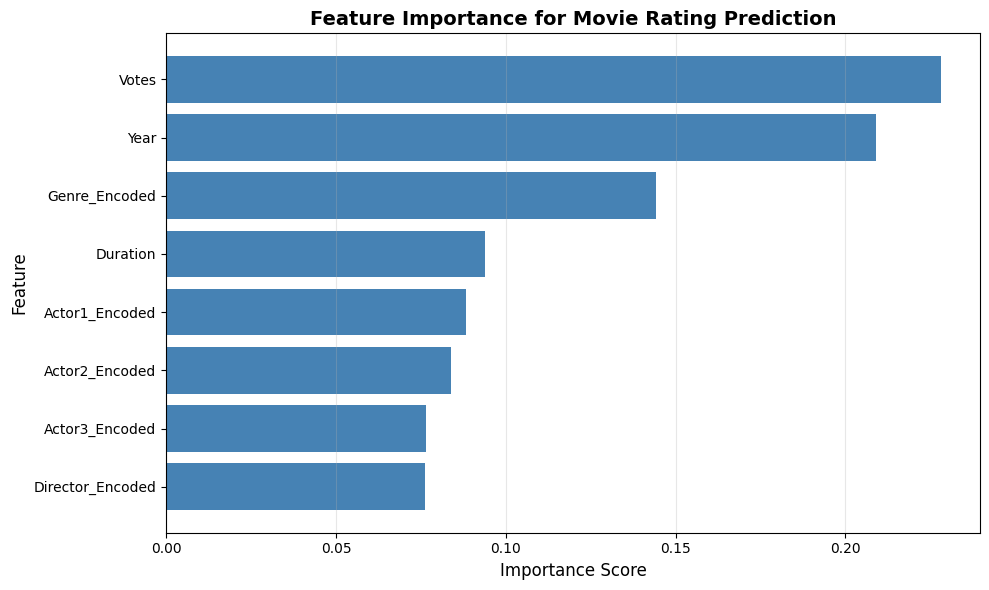


Top 5 Most Important Features:
          Feature  Importance
3           Votes    0.228209
0            Year    0.209120
2   Genre_Encoded    0.144169
1        Duration    0.093930
5  Actor1_Encoded    0.088174


In [45]:
# Extract feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize top features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance for Movie Rating Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print top features
print('\nTop 5 Most Important Features:')
print(feature_importance.head())

# Prediction Function

A helper function to predict ratings for new movies using our trained Random Forest model.

In [46]:
def predict_rating(year, duration, genre, votes, director, actor1, actor2, actor3):
    """
    Predict movie rating using the trained Random Forest model.
    
    Parameters:
    -----------
    year : int - Release year
    duration : int - Movie duration in minutes
    genre : str - Movie genre
    votes : int - Number of votes
    director : str - Director name
    actor1, actor2, actor3 : str - Lead actors
    
    Returns:
    --------
    float - Predicted rating (1-10 scale)
    """
    try:
        # Encode categorical features
        genre_enc = genre_encoder.transform([genre])[0] if genre in genre_encoder.classes_ else -1
        director_enc = director_encoder.transform([director])[0] if director in director_encoder.classes_ else -1
        actor1_enc = actor1_encoder.transform([actor1])[0] if actor1 in actor1_encoder.classes_ else -1
        actor2_enc = actor2_encoder.transform([actor2])[0] if actor2 in actor2_encoder.classes_ else -1
        actor3_enc = actor3_encoder.transform([actor3])[0] if actor3 in actor3_encoder.classes_ else -1
        
        # Create feature array
        features = np.array([[year, duration, genre_enc, votes, director_enc, actor1_enc, actor2_enc, actor3_enc]])
        
        # Make prediction
        prediction = rf_model.predict(features)[0]
        
        # Clip to valid rating range
        prediction = np.clip(prediction, 1, 10)
        
        return round(prediction, 2)
    except Exception as e:
        print(f"Error making prediction: {e}")
        return None

# Test the prediction function
print('Testing Prediction Function:')
print('=' * 50)
test_rating = predict_rating(
    year=2020,
    duration=120,
    genre='Drama',
    votes=10000,
    director='Christopher Nolan',
    actor1='Leonardo DiCaprio',
    actor2='Tom Hardy',
    actor3='Marion Cotillard'
)
print(f"Predicted Rating: {test_rating}/10")
print('=' * 50)

Testing Prediction Function:
Predicted Rating: 6.26/10
